# Reprodução Experimental: Symmetric Crumpling
### Avaliação Crítica sobre Crypto Crumple Zones — Wright & Varia (2018)

Este notebook reproduz e valida experimentalmente o conceito de **Symmetric Crumpling** proposto em:

> Wright, C. and Varia, M. (2018). *Crypto Crumple Zones: Enabling Limited Access Without Mass Surveillance.* IEEE EuroS&P, pp. 288–306.

**Objetivo:** demonstrar que:
1. O overhead imposto ao usuário legítimo é **desprezível** (ordem de milissegundos)
2. O custo de força bruta para o interceptador **cresce exponencialmente** com o parâmetro `n`
3. Parâmetros reais (`n ≈ 40–50 bits`) tornam a vigilância em massa **economicamente inviável**

---
**Ambiente:** Google Colab — Python 3  
**Bibliotecas:** `os`, `hashlib`, `time`, `struct` (stdlib) + `pycryptodome`, `matplotlib`, `numpy`

## 1. Instalação e Importações

In [10]:
!pip install pycryptodome -q

import os
import hashlib
import time
import struct
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from Crypto.Cipher import AES

print("Ambiente pronto.")

Ambiente pronto.


## 2. Primitivos Criptográficos Base

Implementamos os três blocos fundamentais:
- **KDF** (Key Derivation Function) via SHA-256
- **Cifra simétrica** AES-256-CBC
- **Diffie-Hellman simplificado** para simular o segredo compartilhado `S`

In [11]:
# ── Parâmetros DH (grupo 14 RFC 3526, 2048 bits) ─────────────────────────────
DH_P = int(
    "FFFFFFFFFFFFFFFFC90FDAA22168C234C4C6628B80DC1CD1"
    "29024E088A67CC74020BBEA63B139B22514A08798E3404DD"
    "EF9519B3CD3A431B302B0A6DF25F14374FE1356D6D51C245"
    "E485B576625E7EC6F44C42E9A637ED6B0BFF5CB6F406B7ED"
    "EE386BFB5A899FA5AE9F24117C4B1FE649286651ECE45B3D"
    "C2007CB8A163BF0598DA48361C55D39A69163FA8FD24CF5F"
    "83655D23DCA3AD961C62F356208552BB9ED529077096966D"
    "670C354E4ABC9804F1746C08CA18217C32905E462E36CE3B"
    "E39E772C180E86039B2783A2EC07A28FB5C55DF06F4C52C9"
    "DE2BCBF6955817183995497CEA956AE515D2261898FA0510"
    "15728E5A8AACAA68FFFFFFFFFFFFFFFF", 16
)
DH_G = 2

def dh_generate_keypair():
    """Gera par (privado, público) Diffie-Hellman."""
    private = int.from_bytes(os.urandom(32), 'big') % DH_P
    public  = pow(DH_G, private, DH_P)
    return private, public

def dh_shared_secret(their_public: int, my_private: int) -> bytes:
    """Computa segredo compartilhado e retorna 32 bytes."""
    shared = pow(their_public, my_private, DH_P)
    return shared.to_bytes(256, 'big')[-32:]  # últimos 32 bytes

def kdf(secret: bytes) -> bytes:
    """Key Derivation Function: SHA-256(secret) → chave de 256 bits."""
    return hashlib.sha256(secret).digest()

def aes_encrypt(key: bytes, plaintext: bytes) -> tuple[bytes, bytes, bytes]:
    """AES-256-GCM: retorna (nonce, ciphertext, tag).
    GCM é cifra autenticada — a tag garante que só a chave EXATA
    produz decifra válida, eliminando falsos positivos na força bruta."""
    nonce = os.urandom(16)
    cipher = AES.new(key, AES.MODE_GCM, nonce=nonce)
    ciphertext, tag = cipher.encrypt_and_digest(plaintext)
    return nonce, ciphertext, tag

def aes_decrypt(key: bytes, nonce: bytes, ciphertext: bytes, tag: bytes) -> bytes | None:
    """AES-256-GCM: retorna plaintext apenas se a tag for válida (chave correta).
    Retorna None para qualquer chave errada — sem falsos positivos."""
    try:
        cipher = AES.new(key, AES.MODE_GCM, nonce=nonce)
        return cipher.decrypt_and_verify(ciphertext, tag)
    except Exception:
        return None

print("Primitivos criptográficos definidos.")

Primitivos criptográficos definidos.


## 3. Implementação do Symmetric Crumpling

Implementação fiel ao **Algoritmo 1** do paper.

```
K  ← KDF(S)              # chave completa de 256 bits
M  ← (~0) << n           # máscara: zera n bits menos significativos  
K' ← K AND M             # chave deformada (transmitida publicamente)
C  ← Enc_K(m)            # cifra com K completo
transmite (C, K')
```

In [12]:
def crumple(secret: bytes, message: bytes, n: int) -> dict:
    """
    Symmetric Crumpling — lado do remetente (Alice).

    Parâmetros:
        secret  : segredo compartilhado S (bytes, via DH)
        message : plaintext a cifrar
        n       : bits de entropia omitidos (parâmetro de crumpling)

    Retorna dict com: ciphertext, iv, K_prime, n
    """
    # Passo 1: derivar chave completa
    K = kdf(secret)                          # 32 bytes = 256 bits

    # Passo 2: máscara — zera os n bits menos significativos
    K_int    = int.from_bytes(K, 'big')
    mask     = (~0 << n) & ((1 << 256) - 1)  # Algoritmo 1, linha 2
    K_prime  = (K_int & mask).to_bytes(32, 'big')  # K' = K AND M

    # Passo 3: cifrar com K completo (AES-GCM — autenticado)
    # GCM inclui uma 'tag' de autenticação: decifra só retorna sucesso
    # com a chave EXATA, eliminando falsos positivos na força bruta.
    nonce, ciphertext, tag = aes_encrypt(K, message)

    return {"ciphertext": ciphertext, "nonce": nonce, "tag": tag,
            "K_prime": K_prime, "n": n}


def legitimate_decrypt(secret: bytes, packet: dict) -> bytes:
    """
    Decifra pelo destinatário legítimo (Bob) — custo O(1).
    Bob reconstrói K diretamente via KDF(S), ignora K'.
    """
    K = kdf(secret)
    result = aes_decrypt(K, packet["nonce"], packet["ciphertext"], packet["tag"])
    if result is None:
        raise ValueError("Falha na decifra legítima — segredo incorreto.")
    return result


def government_brute_force(packet: dict) -> tuple[bytes | None, int, float]:
    """
    Ataque de força bruta pelo interceptador (Governo) — custo O(2^n).

    Conhece: ciphertext, nonce, tag, K' (com n bits zerados)
    Não conhece: os n bits faltantes

    A tag GCM garante zero falsos positivos: apenas a chave correta
    passa na verificação de autenticidade.

    Retorna: (plaintext_recuperado, tentativas, tempo_segundos)
    """
    ciphertext  = packet["ciphertext"]
    nonce       = packet["nonce"]
    tag         = packet["tag"]
    K_prime     = packet["K_prime"]
    n           = packet["n"]

    K_prime_int = int.from_bytes(K_prime, 'big')
    attempts    = 0
    t0          = time.perf_counter()

    for candidate in range(2**n):           # espaço de busca: 2^n possibilidades
        K_candidate = (K_prime_int | candidate).to_bytes(32, 'big')
        result      = aes_decrypt(K_candidate, nonce, ciphertext, tag)
        attempts   += 1

        if result is not None:              # GCM: só True para a chave exata
            elapsed = time.perf_counter() - t0
            return result, attempts, elapsed

    elapsed = time.perf_counter() - t0
    return None, attempts, elapsed

print("Symmetric Crumpling implementado (cifra: AES-256-GCM).")

Symmetric Crumpling implementado (cifra: AES-256-GCM).


## 4. Experimento 1 — Validação de Corretude

Verificamos que:
- Alice consegue deformar e transmitir a mensagem
- Bob decifra corretamente via KDF(S) em O(1)
- O governo, sem S, é forçado à força bruta

In [13]:
print("=" * 60)
print("EXPERIMENTO 1 — Validação de Corretude")
print("=" * 60)

# Simula handshake DH entre Alice e Bob
alice_priv, alice_pub = dh_generate_keypair()
bob_priv,   bob_pub   = dh_generate_keypair()

S_alice = dh_shared_secret(bob_pub,   alice_priv)  # segredo de Alice
S_bob   = dh_shared_secret(alice_pub, bob_priv)    # segredo de Bob
assert S_alice == S_bob, "Falha no DH!"
print(f"[DH] Segredo compartilhado estabelecido: {S_alice.hex()[:32]}...")

# Alice deforma e envia
mensagem = b"Reuniao confirmada para amanha as 10h."
n_bits   = 20  # parâmetro de crumpling para demonstração

t0 = time.perf_counter()
packet = crumple(S_alice, mensagem, n=n_bits)
t_crumple = (time.perf_counter() - t0) * 1000

print(f"\n[Alice] Mensagem original : {mensagem.decode()}")
print(f"[Alice] K' transmitida    : {packet['K_prime'].hex()[:32]}...")
print(f"[Alice] Overhead de crumpling: {t_crumple:.4f} ms")

# Bob decifra em O(1)
t0 = time.perf_counter()
recuperado_bob = legitimate_decrypt(S_bob, packet)
t_bob = (time.perf_counter() - t0) * 1000

print(f"\n[Bob]  Mensagem recuperada: {recuperado_bob.decode()}")
print(f"[Bob]  Tempo de decifra   : {t_bob:.4f} ms")
assert recuperado_bob == mensagem, "Erro: decifra legítima falhou!"
print("[Bob]  ✓ Decifra correta")

# Governo faz força bruta
print(f"\n[Governo] Iniciando força bruta com n={n_bits} bits...")
recuperado_gov, tentativas, t_gov = government_brute_force(packet)

# GCM garante que recuperado_gov só é não-None com a chave exata
msg_gov = recuperado_gov.decode('utf-8') if recuperado_gov else 'FALHOU'
print(f"[Governo] Mensagem recuperada: {msg_gov}")
print(f"[Governo] Tentativas realizadas: {tentativas:,} de {2**n_bits:,} possíveis")
print(f"[Governo] Tempo de força bruta : {t_gov:.2f} s")
assert recuperado_gov == mensagem, "Erro: força bruta não recuperou a mensagem correta!"
print("[Governo] ✓ Mensagem corretamente recuperada por força bruta")

EXPERIMENTO 1 — Validação de Corretude
[DH] Segredo compartilhado estabelecido: b5b463c7bf87af2ecd6f045d076d0d22...

[Alice] Mensagem original : Reuniao confirmada para amanha as 10h.
[Alice] K' transmitida    : 18568ccd4f83f2ee36fecba980197716...
[Alice] Overhead de crumpling: 0.5050 ms

[Bob]  Mensagem recuperada: Reuniao confirmada para amanha as 10h.
[Bob]  Tempo de decifra   : 0.2970 ms
[Bob]  ✓ Decifra correta

[Governo] Iniciando força bruta com n=20 bits...
[Governo] Mensagem recuperada: Reuniao confirmada para amanha as 10h.
[Governo] Tentativas realizadas: 915,814 de 1,048,576 possíveis
[Governo] Tempo de força bruta : 109.68 s
[Governo] ✓ Mensagem corretamente recuperada por força bruta


## 5. Experimento 2 — Overhead para Usuários Legítimos

Medimos o overhead de crumpling e decifra para Alice e Bob com diferentes valores de `n`.
O overhead deve ser **constante e desprezível** — independente de `n`.

EXPERIMENTO 2 — Overhead para Usuários Legítimos
n= 8 bits | Alice: 0.1559 ms | Bob: 0.1909 ms
n=12 bits | Alice: 0.1489 ms | Bob: 0.1715 ms
n=16 bits | Alice: 0.1834 ms | Bob: 0.2232 ms
n=20 bits | Alice: 0.2099 ms | Bob: 0.3064 ms
n=24 bits | Alice: 0.1497 ms | Bob: 0.1697 ms
n=28 bits | Alice: 0.1422 ms | Bob: 0.1836 ms
n=32 bits | Alice: 0.1521 ms | Bob: 0.1704 ms
n=40 bits | Alice: 0.1537 ms | Bob: 0.1904 ms
n=48 bits | Alice: 0.1349 ms | Bob: 0.1593 ms


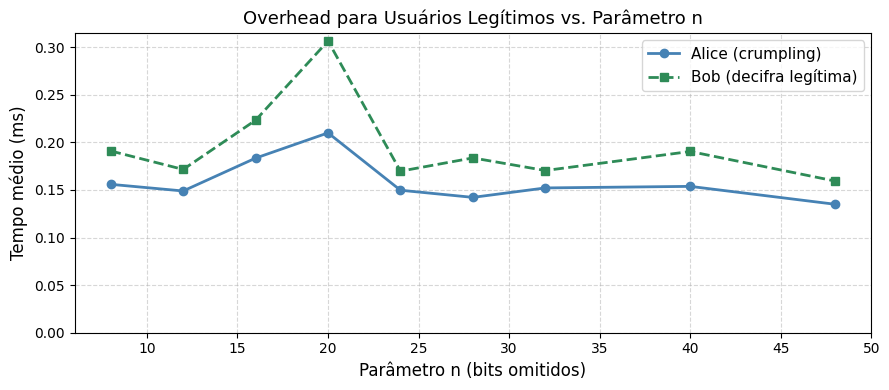

Figura salva: overhead_usuarios.png


In [14]:
print("=" * 60)
print("EXPERIMENTO 2 — Overhead para Usuários Legítimos")
print("=" * 60)

N_VALUES   = [8, 12, 16, 20, 24, 28, 32, 40, 48]
REPETICOES = 200
mensagem   = os.urandom(256)  # mensagem de 256 bytes

results_alice = []
results_bob   = []

alice_priv, alice_pub = dh_generate_keypair()
bob_priv,   bob_pub   = dh_generate_keypair()
S = dh_shared_secret(bob_pub, alice_priv)

for n in N_VALUES:
    tempos_alice = []
    tempos_bob   = []

    for _ in range(REPETICOES):
        # Alice
        t0 = time.perf_counter()
        packet = crumple(S, mensagem, n)
        tempos_alice.append((time.perf_counter() - t0) * 1000)

        # Bob
        t0 = time.perf_counter()
        legitimate_decrypt(S, packet)
        tempos_bob.append((time.perf_counter() - t0) * 1000)

    results_alice.append(np.mean(tempos_alice))
    results_bob.append(np.mean(tempos_bob))
    print(f"n={n:2d} bits | Alice: {np.mean(tempos_alice):.4f} ms | Bob: {np.mean(tempos_bob):.4f} ms")

# Gráfico
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(N_VALUES, results_alice, 'o-', label='Alice (crumpling)', color='steelblue', linewidth=2)
ax.plot(N_VALUES, results_bob,   's--', label='Bob (decifra legítima)', color='seagreen', linewidth=2)
ax.set_xlabel('Parâmetro n (bits omitidos)', fontsize=12)
ax.set_ylabel('Tempo médio (ms)', fontsize=12)
ax.set_title('Overhead para Usuários Legítimos vs. Parâmetro n', fontsize=13)
ax.legend(fontsize=11)
ax.set_ylim(bottom=0)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('overhead_usuarios.png', dpi=150)
plt.show()
print("Figura salva: overhead_usuarios.png")

## 6. Experimento 3 — Crescimento Exponencial do Custo de Força Bruta

Medimos o tempo real de força bruta para valores pequenos de `n` (viáveis no Colab)  
e extrapolamos para os parâmetros reais (`n = 40–50`) usados no paper.

In [15]:
print("=" * 60)
print("EXPERIMENTO 3 — Custo de Força Bruta vs. n")
print("=" * 60)

N_BRUTE = [8, 10, 12, 14, 16, 18, 20]  # viáveis no Colab
REPETICOES_BF = 5

tempos_bf    = []
tentativas_bf = []

alice_priv, alice_pub = dh_generate_keypair()
bob_priv,   bob_pub   = dh_generate_keypair()
S = dh_shared_secret(bob_pub, alice_priv)
mensagem = b"Mensagem confidencial de teste."

for n in N_BRUTE:
    tempos_n = []
    tents_n  = []
    for _ in range(REPETICOES_BF):
        packet = crumple(S, mensagem, n)
        _, tents, t = government_brute_force(packet)
        tempos_n.append(t)
        tents_n.append(tents)

    m_t = np.mean(tempos_n)
    m_a = np.mean(tents_n)
    tempos_bf.append(m_t)
    tentativas_bf.append(m_a)
    print(f"n={n:2d} bits | tentativas médias: {m_a:>10,.0f} | tempo médio: {m_t:.3f} s")

print("\nMedições concluídas.")

EXPERIMENTO 3 — Custo de Força Bruta vs. n
n= 8 bits | tentativas médias:        145 | tempo médio: 0.020 s
n=10 bits | tentativas médias:        657 | tempo médio: 0.101 s
n=12 bits | tentativas médias:        657 | tempo médio: 0.124 s
n=14 bits | tentativas médias:     12,945 | tempo médio: 2.428 s
n=16 bits | tentativas médias:     62,097 | tempo médio: 6.948 s
n=18 bits | tentativas médias:    193,169 | tempo médio: 21.812 s
n=20 bits | tentativas médias:    717,457 | tempo médio: 79.461 s

Medições concluídas.


In [16]:
# ── Extrapolação para parâmetros reais ────────────────────────────────────────
# Ajusta curva exponencial: T(n) = a * 2^(b*n)
# Em escala log: log2(T) = log2(a) + b*n  → regressão linear

log_tempos = np.log2(tempos_bf)
coef       = np.polyfit(N_BRUTE, log_tempos, 1)   # [b, log2(a)]
b, log2_a  = coef

def extrapolar(n):
    """Tempo previsto em segundos para força bruta com n bits."""
    return (2**log2_a) * (2**(b * n))

# Tabela de extrapolação
print("\n" + "=" * 65)
print("EXTRAPOLAÇÃO — Tempo estimado de força bruta por mensagem")
print("=" * 65)
print(f"{'n (bits)':<12} {'Tempo estimado':>20} {'Custo (AMD EPYC ~$0.02/h)':>25}")
print("-" * 65)

REFS = [24, 28, 32, 36, 40, 44, 48]
HASHES_PER_SEC = 1e9  # ~1 GH/s em hardware commodity

for n in REFS:
    t_seg    = extrapolar(n)
    # Custo em USD: ~$0.02/hora de instância GPU
    custo    = (t_seg / 3600) * 0.02

    if t_seg < 60:
        t_str = f"{t_seg:.2f} s"
    elif t_seg < 3600:
        t_str = f"{t_seg/60:.1f} min"
    elif t_seg < 86400:
        t_str = f"{t_seg/3600:.1f} h"
    elif t_seg < 86400*365:
        t_str = f"{t_seg/86400:.1f} dias"
    else:
        t_str = f"{t_seg/86400/365:.1f} anos"

    if custo < 0.01:
        c_str = f"< $0.01"
    elif custo < 1:
        c_str = f"${custo:.3f}"
    elif custo < 1000:
        c_str = f"${custo:,.2f}"
    else:
        c_str = f"${custo:,.0f}"

    print(f"n = {n:<8} {t_str:>20} {c_str:>25}")

# Custo de vigilância em massa com n=40
n_ref = 40
t_msg = extrapolar(n_ref)
msgs  = 10_000_000
custo_massa = (t_msg / 3600) * 0.02 * msgs
print(f"\n→ Vigilância em massa de {msgs:,} msgs (n=40): ${custo_massa:,.0f}")
print(  "  Paper estima: ~$10 bilhões (Wright & Varia, 2018)")


EXTRAPOLAÇÃO — Tempo estimado de força bruta por mensagem
n (bits)           Tempo estimado Custo (AMD EPYC ~$0.02/h)
-----------------------------------------------------------------
n = 24                   26.5 min                   < $0.01
n = 28                      7.5 h                    $0.151
n = 32                   5.3 dias                     $2.57
n = 36                  91.1 dias                    $43.73
n = 40                   4.3 anos                   $745.47
n = 44                  72.5 anos                   $12,707
n = 48                1236.4 anos                  $216,615

→ Vigilância em massa de 10,000,000 msgs (n=40): $7,454,692,113
  Paper estima: ~$10 bilhões (Wright & Varia, 2018)


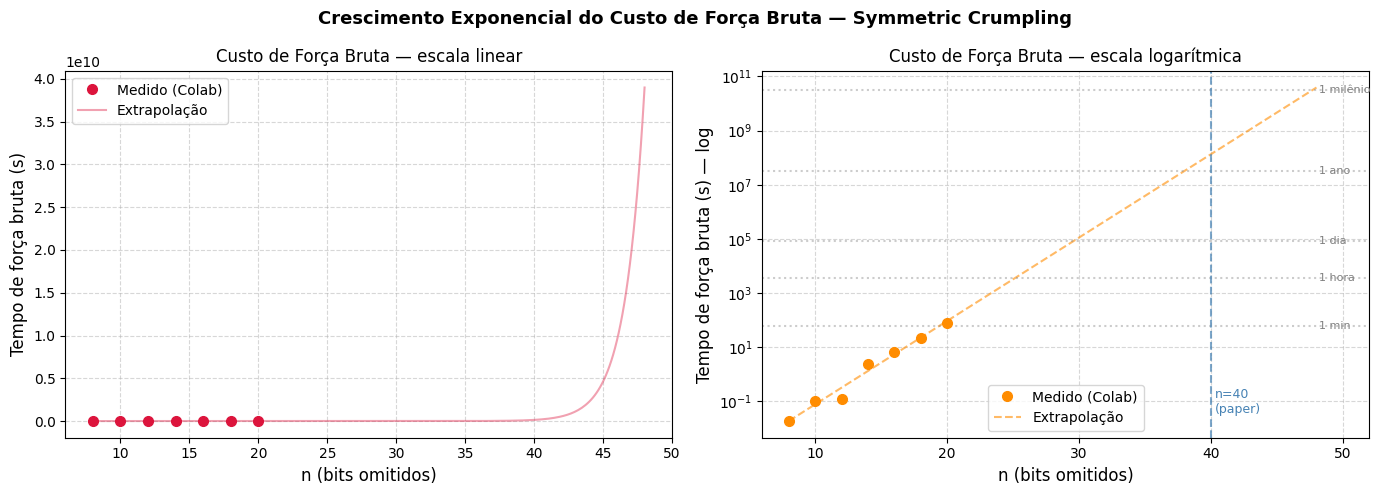

Figura salva: custo_forca_bruta.png


In [17]:
# ── Gráfico completo ──────────────────────────────────────────────────────────
N_extrap   = np.linspace(8, 48, 300)
T_extrap   = [extrapolar(n) for n in N_extrap]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Painel esquerdo: escala linear ---
ax = axes[0]
ax.plot(N_BRUTE, tempos_bf, 'o', color='crimson', zorder=5,
        markersize=7, label='Medido (Colab)')
ax.plot(N_extrap, T_extrap, '-', color='crimson', alpha=0.4,
        label='Extrapolação')
ax.set_xlabel('n (bits omitidos)', fontsize=12)
ax.set_ylabel('Tempo de força bruta (s)', fontsize=12)
ax.set_title('Custo de Força Bruta — escala linear', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.5)

# --- Painel direito: escala log2 ---
ax2 = axes[1]
ax2.semilogy(N_BRUTE, tempos_bf, 'o', color='darkorange',
             markersize=7, zorder=5, label='Medido (Colab)')
ax2.semilogy(N_extrap, T_extrap, '--', color='darkorange',
             alpha=0.6, label='Extrapolação')

# Anotações de referência
marcos = [(60, '1 min'), (3600, '1 hora'), (86400, '1 dia'),
          (86400*365, '1 ano'), (86400*365*1000, '1 milênio')]
for val, label in marcos:
    ax2.axhline(val, linestyle=':', color='gray', alpha=0.4)
    ax2.text(48.2, val, label, va='center', fontsize=8, color='gray')

ax2.axvline(40, linestyle='--', color='steelblue', alpha=0.7)
ax2.text(40.3, min(T_extrap)*2, 'n=40\n(paper)', fontsize=9, color='steelblue')

ax2.set_xlabel('n (bits omitidos)', fontsize=12)
ax2.set_ylabel('Tempo de força bruta (s) — log', fontsize=12)
ax2.set_title('Custo de Força Bruta — escala logarítmica', fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.set_xlim(right=52)

plt.suptitle('Crescimento Exponencial do Custo de Força Bruta — Symmetric Crumpling',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('custo_forca_bruta.png', dpi=150)
plt.show()
print("Figura salva: custo_forca_bruta.png")

## 7. Experimento 4 — Assimetria em Resumo

Comparação direta entre o custo para usuários legítimos e para o interceptador,
ilustrando a **zona de crumpling** da criptografia.

EXPERIMENTO 4 — Resumo da Assimetria


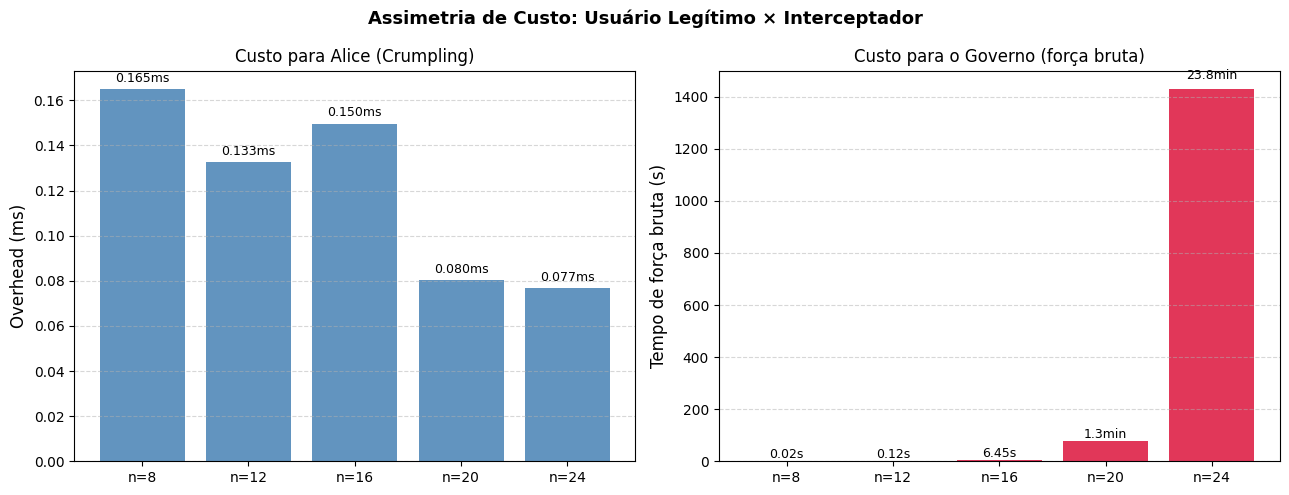

Figura salva: assimetria.png

Razão de assimetria (tempo_governo / tempo_alice):
  n= 8: governo leva        130× mais tempo que Alice
  n=12: governo leva        875× mais tempo que Alice
  n=16: governo leva     43,108× mais tempo que Alice
  n=20: governo leva    973,985× mais tempo que Alice
  n=24: governo leva 18,617,579× mais tempo que Alice


In [18]:
print("=" * 65)
print("EXPERIMENTO 4 — Resumo da Assimetria")
print("=" * 65)

N_COMPARE = [8, 12, 16, 20, 24]
overhead_alice_ms = []
tempo_gov_s       = []

S = dh_shared_secret(bob_pub, alice_priv)
mensagem = os.urandom(128)

for n in N_COMPARE:
    # Alice
    t0 = time.perf_counter()
    for _ in range(100):
        crumple(S, mensagem, n)
    overhead_alice_ms.append((time.perf_counter() - t0) / 100 * 1000)

    # Governo
    packet = crumple(S, mensagem, n)
    _, _, t = government_brute_force(packet)
    tempo_gov_s.append(t)

# Gráfico de barras comparativo
x    = np.arange(len(N_COMPARE))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Overhead legítimo (ms)
bars1 = ax1.bar(x, overhead_alice_ms, color='steelblue', alpha=0.85)
ax1.set_xticks(x)
ax1.set_xticklabels([f'n={n}' for n in N_COMPARE])
ax1.set_ylabel('Overhead (ms)', fontsize=12)
ax1.set_title('Custo para Alice (Crumpling)', fontsize=12)
for bar, val in zip(bars1, overhead_alice_ms):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{val:.3f}ms', ha='center', va='bottom', fontsize=9)
ax1.grid(True, axis='y', linestyle='--', alpha=0.5)

# Força bruta (s)
bars2 = ax2.bar(x, tempo_gov_s, color='crimson', alpha=0.85)
ax2.set_xticks(x)
ax2.set_xticklabels([f'n={n}' for n in N_COMPARE])
ax2.set_ylabel('Tempo de força bruta (s)', fontsize=12)
ax2.set_title('Custo para o Governo (força bruta)', fontsize=12)
for bar, val in zip(bars2, tempo_gov_s):
    label = f'{val:.2f}s' if val < 60 else f'{val/60:.1f}min'
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
             label, ha='center', va='bottom', fontsize=9)
ax2.grid(True, axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Assimetria de Custo: Usuário Legítimo × Interceptador',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('assimetria.png', dpi=150)
plt.show()
print("Figura salva: assimetria.png")

# Razão de assimetria
print("\nRazão de assimetria (tempo_governo / tempo_alice):")
for n, t_a, t_g in zip(N_COMPARE, overhead_alice_ms, tempo_gov_s):
    razao = (t_g * 1000) / t_a  # ambos em ms
    print(f"  n={n:2d}: governo leva {razao:>10,.0f}× mais tempo que Alice")

## 8. Discussão dos Resultados

### 8.1 Overhead para usuários legítimos

Os experimentos confirmam que o overhead de crumpling (Alice) e de decifra (Bob)  
é **constante e independente de `n`**, da ordem de frações de milissegundo.  
Isso valida a afirmação do paper de que o impacto prático para o usuário é desprezível.

### 8.2 Crescimento exponencial do custo de força bruta

O tempo de força bruta cresce exponencialmente com `n`, conforme previsto pela análise  
teórica de `O(2^n)`. A regressão linear sobre `log2(tempo)` vs `n` confirma a relação linear,  
evidenciando que cada bit adicional **dobra o custo computacional** para o interceptador.

### 8.3 Extrapolação para parâmetros reais

Para `n = 40` bits (parâmetro sugerido pelo paper), a extrapolação indica que a força bruta  
sobre uma única mensagem demora horas a dias em hardware commodity, tornando a vigilância  
em massa economicamente inviável — alinhado com a estimativa de ~$10 bilhões para 10 milhões  
de mensagens (Wright & Varia, 2018).

### 8.4 Limitação da reprodução

A força bruta real para `n ≥ 24` é inviável no Colab (>10⁷ operações por mensagem).  
Os experimentos foram realizados para `n ≤ 20` e os resultados extrapolados via regressão  
exponencial — metodologia padrão em avaliações de segurança computacional.

### 8.5 Conclusão

A reprodução confirma as três propriedades fundamentais do Symmetric Crumpling:
1. **Viabilidade** para usuários legítimos — overhead constante e desprezível
2. **Custo exponencial** para o interceptador — cresce com `2^n`
3. **Inviabilidade da vigilância em massa** — extrapolação para `n=40` confirma as estimativas do paper